In [ ]:
#!pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 39.5 MB/s eta 0:00:00


In [4]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, initializers
from sklearn.model_selection import train_test_split
import matplotlib.ticker as ticker
from keras.layers import Conv1D
from tensorflow.keras.models import Model
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import seaborn as sns

In [6]:
tree_light_data = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")["alazar_data"]
tree_light_parameters = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")["alazar_parameters"]
tree_dark_data = uproot.open("TES1-0.3RN-5GHz-50MHz-extrinsic-2d-trigger-10mV.root")["alazar_data"]
tree_dark_parameters = uproot.open("TES1-0.3RN-5GHz-50MHz-extrinsic-2d-trigger-10mV.root")["alazar_parameters"]
LIGHT_PULSES = tree_light_data["dataChA"].array(library="np")
DARK_PULSES = tree_dark_data["dataChA"].array(library="np")

In [6]:
def mostrar_arbol_root(root_file):
    """
    OBJ: Muestra la estructura completa de un fichero ROOT.
    PARAMS:
    root_file : uproot.reading.ReadOnlyDirectory
                dataset cargado
    """

    def recorrer(obj, nivel=0):

        indentacion = "│   " * nivel

        for clave in obj.keys():

            print(f"{indentacion}├── {clave}")

            try:
                hijo = obj[clave]

                if isinstance(hijo, uproot.reading.ReadOnlyDirectory):
                    recorrer(hijo, nivel + 1)

            except Exception:
                pass

    print(f"\nEstructura de: {root_file.file_path}\n")
    recorrer(root_file)

In [7]:
#formara parte del main
light_dataset_raw = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")
dark_dataset_raw = uproot.open("TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root")
#formara parte del menu
mostrar_arbol_root(light_dataset_raw)
mostrar_arbol_root(dark_dataset_raw)


Estructura de: TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root

├── alazar_data;3
├── alazar_parameters;1

Estructura de: TES1-0.3RN-5GHz-50MHz-laser-5s-trigger-10mV.root

├── alazar_data;3
├── alazar_parameters;1


In [7]:
print(tree_light_data.keys())
print(tree_light_parameters.keys())
triggerChA_light = tree_light_data["triggerChA"].array(library="np")
print(LIGHT_PULSES.shape)
print(DARK_PULSES.shape)
print(triggerChA_light.shape)

['samplingFrequency', 'timeStamp', 'startTime', 'DAQ', 'AlpsIOVersion', 'AlazarVersion', 'AlazarApiVersion', 'AlazarDriverVersion', 'cooldown', 'recharge', 'dataChA', 'triggerChA']
['AlpsIOVersion', 'AlazarVersion', 'AlazarApiVersion', 'AlazarDriverVersion', 'DAQ', 'd_or_s', 'cooldown', 'WP1', 'GBWP1', 'WP2', 'GBWP2', 'samplingFrequency', 'adquisition_type', 'adquisition_time', 'type_of_measurement', 'comments', 'number_of_processors', 'thr_1', 'thr_2', 'PreSamples', 'PostSamples', 'filtered_trigger', 'order_1', 'frequency_1', 'order_2', 'frequency_2', 'save_filtered_data']
(4722,)
(8872,)
(4722,)


In [6]:
print(LIGHT_PULSES.shape)
print(triggerChA_light.shape)

(4722,)
(4722,)


In [7]:
print(LIGHT_PULSES[0][:10])
print(triggerChA_light[0])

[0.0035668  0.00314717 0.00379568 0.00425345 0.00448234 0.00455863
 0.00452049 0.00444419 0.00471122 0.00452049]
True


### Estudio y Análisis de los datos

Muestras por traza: (10000,)


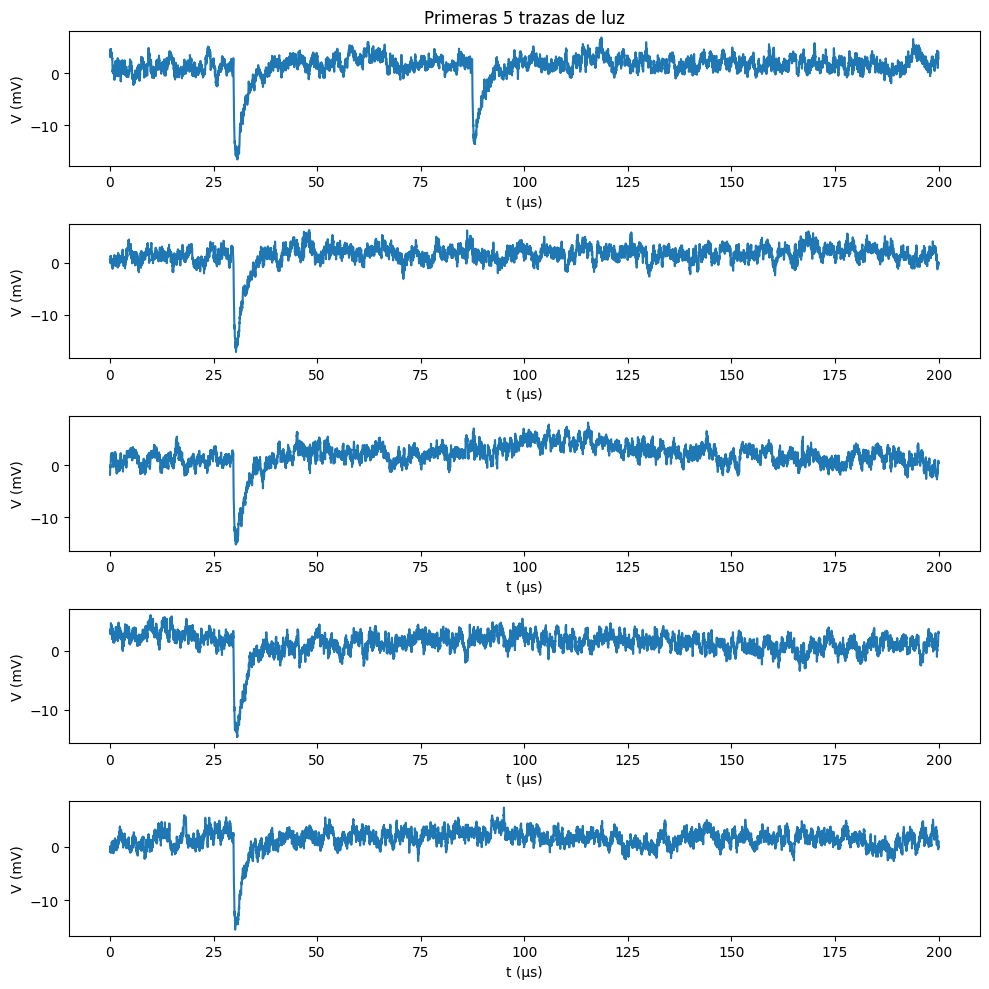

Amplitud mínima media: -15.98 mV
Amplitud mínima std:   1.27 mV
Amplitud mínima max:   -11.20 mV


In [8]:
# Ver cuántas muestras tiene una traza
print(f"Muestras por traza: {LIGHT_PULSES[0].shape}")

# Convertir a mV y plotear las primeras 5 trazas
fig, axes = plt.subplots(5, 1, figsize=(10, 10))
for i in range(5):
    t = np.arange(len(LIGHT_PULSES[i])) / 50  # eje temporal en µs (50 MHz)
    axes[i].plot(t, LIGHT_PULSES[i] * 1000)    # convertir a mV
    axes[i].set_ylabel("V (mV)")
    axes[i].set_xlabel("t (µs)")
axes[0].set_title("Primeras 5 trazas de luz")
plt.tight_layout()
plt.savefig("trazas_luz.png", dpi=100)
plt.show()

# Estadísticas básicas del dataset completo
all_mins = np.array([np.min(p) for p in LIGHT_PULSES]) * 1000
print(f"Amplitud mínima media: {np.mean(all_mins):.2f} mV")
print(f"Amplitud mínima std:   {np.std(all_mins):.2f} mV")
print(f"Amplitud mínima max:   {np.max(all_mins):.2f} mV")

Se representan los 10 primeros pulsos Light y Dark para tener una tenemos una idea general de la forma que tienen.

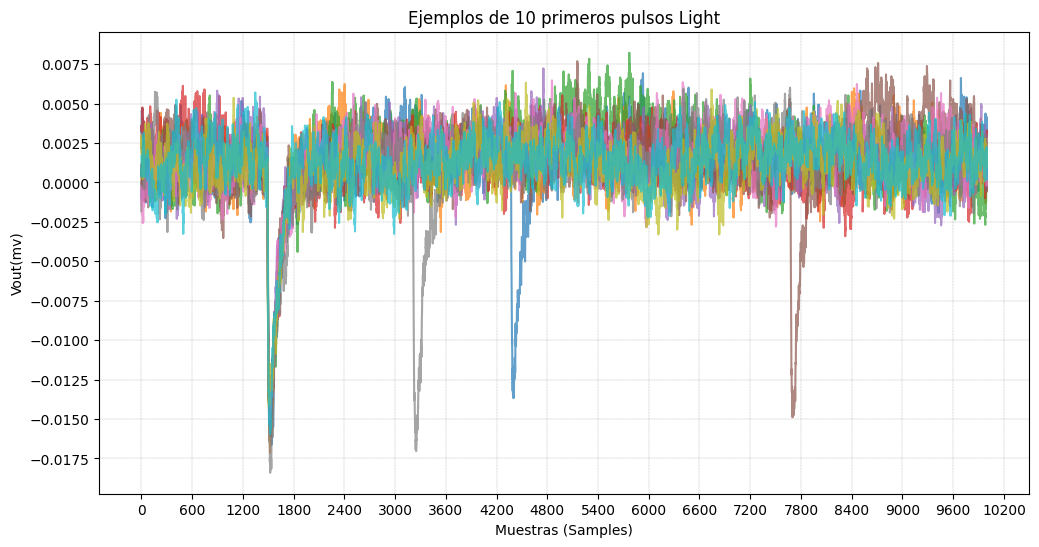

In [8]:
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(LIGHT_PULSES[i], alpha=0.7)

plt.title("Ejemplos de 10 primeros pulsos Light")
plt.xlabel("Muestras (Samples)")
plt.ylabel("Vout(mv)")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.2)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.xaxis.set_major_locator(ticker.MultipleLocator(600))
plt.show()

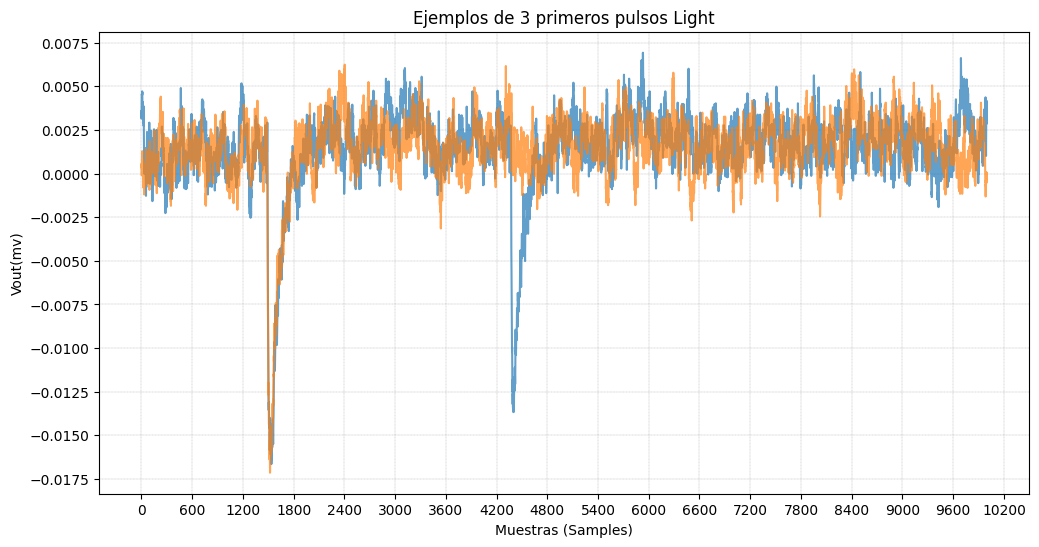

In [9]:
plt.figure(figsize=(12, 6))
for i in range(2):
    plt.plot(LIGHT_PULSES[i], alpha=0.7)

plt.title("Ejemplos de 3 primeros pulsos Light")
plt.xlabel("Muestras (Samples)")
plt.ylabel("Vout(mv)")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.2)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.xaxis.set_major_locator(ticker.MultipleLocator(600))
plt.show()

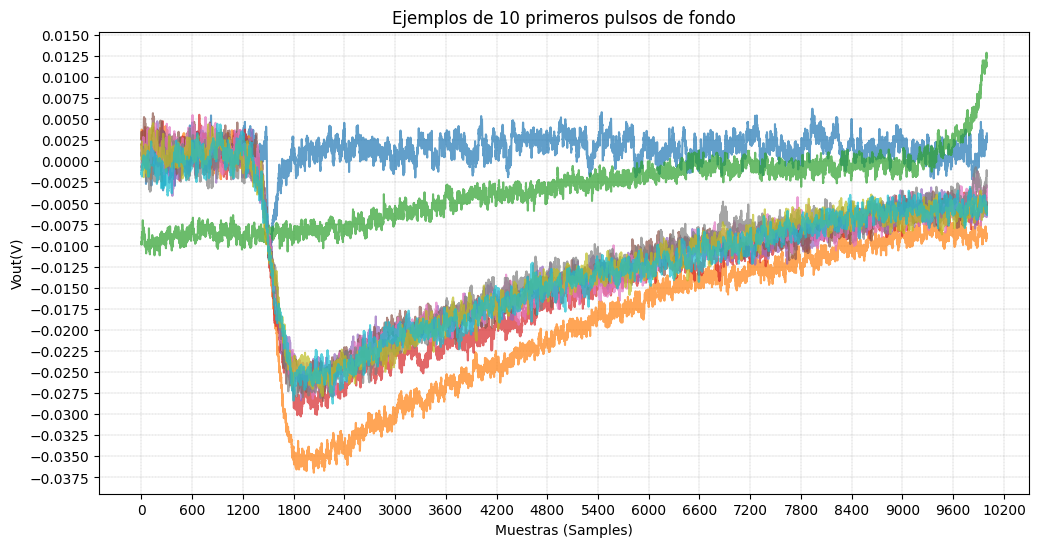

In [10]:
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(DARK_PULSES[i], alpha=0.7)

plt.title("Ejemplos de 10 primeros pulsos de fondo")
plt.xlabel("Muestras (Samples)")
plt.ylabel("Vout(V)")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.2)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.xaxis.set_major_locator(ticker.MultipleLocator(600))
plt.show()

Observamos que los pulsos de ambos conjuntos se concentran en un rango de 1200 a 2500 muestras. Para comprobarlo se van a calcular la media para cada conjunto.

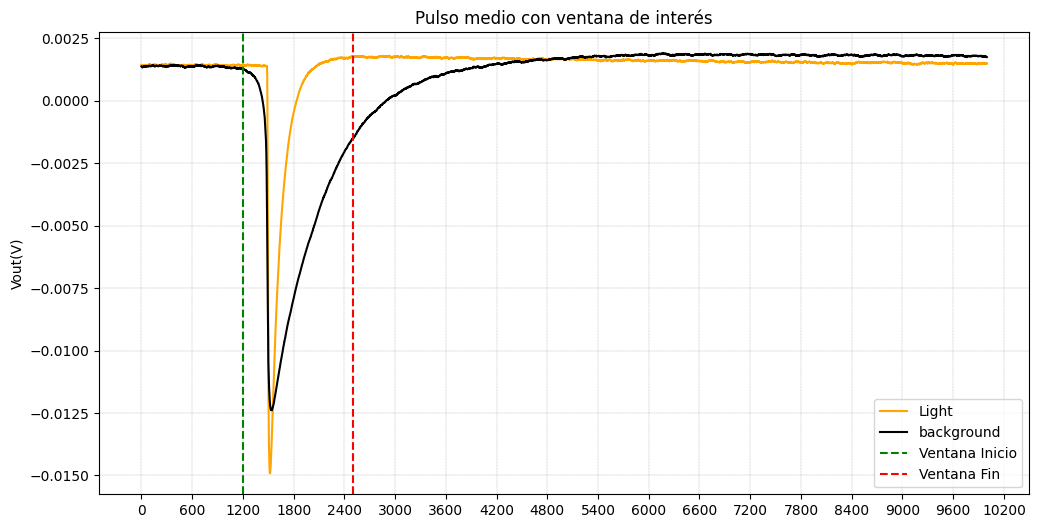

In [11]:
plt.figure(figsize=(12, 6))
mean_light = np.mean(LIGHT_PULSES, axis=0)
mean_dark = np.mean(DARK_PULSES, axis=0)

plt.plot(mean_light, label="Light", color = 'orange')
plt.plot(mean_dark, label="background", color = 'black')

# Se marcan lineas significativas
plt.axvline(x=1200, color='green', linestyle='--', label='Ventana Inicio')
plt.axvline(x=2500, color='red', linestyle='--', label='Ventana Fin')

plt.legend()
plt.title("Pulso medio con ventana de interés")
plt.ylabel("Vout(V)")
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.2)
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0025))
ax.xaxis.set_major_locator(ticker.MultipleLocator(600))
plt.show()

In [ ]:
baseline = np.mean(mean_dark[:1000])

# El mínimo ocurre después de la muestra 1200
min_val_dark = np.min(mean_dark[1200:])
min_val_light = np.min(mean_light[1200:])

# 90% recuperado significa que el valor está al 10% de la amplitud total desde el mínimo
umbral_dark  = min_val_dark  + 0.9 * (baseline - min_val_dark)
umbral_light = min_val_light + 0.9 * (baseline - min_val_light)

print(f"Baseline: {baseline*1000:.3f} mV")
print(f"Mínimo pulso oscuro: {min_val_dark*1000:.3f} mV")
print(f"Mínimo pulso luz:    {min_val_light*1000:.3f} mV")
print(f"Umbral recuperación oscuro: {umbral_dark*1000:.3f} mV")
print(f"Umbral recuperación luz:    {umbral_light*1000:.3f} mV")

# Buscar dónde cada pulso medio cruza su umbral de recuperación
for i, v in enumerate(mean_dark[1200:], start=1200):
    if v >= umbral_dark:
        print(f"\nPulso oscuro al 90% en muestra {i} ({i/50:.1f} µs)")
        break

for i, v in enumerate(mean_light[1200:], start=1200):
    if v >= umbral_light:
        print(f"Pulso de luz al 90% en muestra {i} ({i/50:.1f} µs)")
        break

Baseline: 1.376 mV
Mínimo pulso oscuro: -12.390 mV
Mínimo pulso luz:    -14.912 mV
Umbral recuperación oscuro: -0.001 mV
Umbral recuperación luz:    -0.253 mV

Pulso oscuro al 90% en muestra 1200 (24.0 µs)
Pulso de luz al 90% en muestra 1200 (24.0 µs)


In [12]:
print("Shape:", LIGHT_PULSES.shape)
print("Tipo elemento:", type(LIGHT_PULSES[0]))
print("Shape elemento:", LIGHT_PULSES[0].shape)

Shape: (4722,)
Tipo elemento: <class 'numpy.ndarray'>
Shape elemento: (10000,)


In [13]:
print(LIGHT_PULSES.shape)
print(LIGHT_PULSES.flatten().shape)

(4722,)
(4722,)


In [29]:
print(len(LIGHT_PULSES[0]))

10000


## División del conjunto de datos
Incialmente trabajaremos con los 4722 pulsos. Sin embargo, para reducir la carga computacional durante el entrenamiento del modelo, se ha decidido seleccionar una ventana de muestras significativas. Para ello se ha calculado el pulso medio del conjunto de datos light y dark. Se observa que la media en ambos casos se centra en el margen de muestra de 1000 a 2000 muestras. Ajustando un poco más, se ha tomado como inicio 1300 como inicio. Se observa que los pulsos dark tienen mayor dispersión, para que el modelo tenga más información de los pulsos dark, se ha decidido, tomar como limite final, 2500. Además el usuario puede seleccionar con cuantas muestras quiere entrenar el modelo.

Tal y como esta el código, se seleccionan los 1000 primeros pulsos de cada conjunto. Si queremos que esos mil pulsos de cada tipo sean aleatorio:

In [34]:
N_SAMPLES = 1000
VENTANA_INI = 1300
VENTANA_FIN = 2500

In [30]:
def seleccionar_ventana_muestras(n_samples, inicio, fin):
    """
    OBJ: Recorta cada traza en la ventana fija [inicio:fin] y elimina
    el offset de voltaje usando el baseline previo a la ventana.
    PARAMS:
    n_samples  : (int)Número de muestras a recortar.
    inicio  :  (int)Índice de inicio de la ventana (incluido).
    fin     :  (int)Índice de fin de la ventana (excluido).
    RETURN:
    light_pulses  : (np.ndarray) Trazas recortadas con offset eliminado.
    dark_pulses   : (np.ndarray) Trazas recortadas con offset eliminado.
    """
    assert inicio >= 0, "El índice de inicio debe ser >= 0."
    assert fin <= len(LIGHT_PULSES[0]), (
        f"El índice fin ({fin}) supera la longitud de la traza ({len(LIGHT_PULSES[0])})."
    )
    assert fin <= len(DARK_PULSES[0]), (
        f"El índice fin ({fin}) supera la longitud de la traza ({len(DARK_PULSES[0])})."
    )
    assert inicio < fin, "El índice inicio debe ser menor que fin."

    trazas_light = []
    trazas_dark = []
    trazas_light_test = []
    trazas_dark_test = []
    for traza in LIGHT_PULSES[:n_samples]:
        offset = np.mean(traza[:inicio]) if inicio > 0 else 0.0
        trazas_light.append(traza[inicio:fin] - offset)
    for traza in DARK_PULSES[:n_samples]:
        offset = np.mean(traza[:inicio]) if inicio > 0 else 0.0
        trazas_dark.append(traza[inicio:fin] - offset)
    for traza in LIGHT_PULSES[n_samples:]:
        #offset = np.mean(traza[:inicio]) if inicio > 0 else 0.0
        trazas_light_test.append(traza[inicio:fin])
    for traza in DARK_PULSES[n_samples:]:
        #offset = np.mean(traza[:inicio]) if inicio > 0 else 0.0
        trazas_dark_test.append(traza[inicio:fin])

    input_len = fin - inicio
    print(f"Ventana seleccionada: [{inicio}:{fin}]")
    print(f"Longitud de traza resultante: {input_len} muestras "
          f"({input_len / 50:.1f} µs a 50 MHz)")

    return np.array(trazas_light), np.array(trazas_dark), np.array(trazas_light_test), np.array(trazas_dark_test)

In [ ]:
"""N_SAMPLES = 1000
VENTANA_INI = 1300
VENTANA_FIN = 2500
X_light_cnn = np.array([fila[VENTANA_INI:VENTANA_FIN] for fila in LIGHT_PULSES[:N_SAMPLES].flatten()])
X_dark_cnn = np.array([fila[VENTANA_INI:VENTANA_FIN] for fila in DARK_PULSES[:N_SAMPLES].flatten()])
X_light_cnn_test = np.array([fila[VENTANA_INI:VENTANA_FIN] for fila in LIGHT_PULSES[N_SAMPLES:].flatten()])
X_dark_cnn_test = np.array([fila[VENTANA_INI:VENTANA_FIN] for fila in DARK_PULSES[N_SAMPLES:].flatten()])
print(X_light_cnn.shape)
print(X_light_cnn_test.shape)
print(X_dark_cnn_test.shape)
print(X_dark_cnn.shape)
print(type(X_light_cnn))"""

In [32]:
X_light_cnn, X_dark_cnn, X_light_cnn_test, X_dark_cnn_test = seleccionar_ventana_muestras(N_SAMPLES, VENTANA_INI, VENTANA_FIN)


Ventana seleccionada: [1300:2500]
Longitud de traza resultante: 1200 muestras (24.0 µs a 50 MHz)


In [33]:
print(X_light_cnn.shape)
print(X_light_cnn_test.shape)
print(X_dark_cnn_test.shape)
print(X_dark_cnn.shape)
print(type(X_light_cnn))

(1000, 1200)
(3722, 1200)
(7872, 1200)
(1000, 1200)
<class 'numpy.ndarray'>


### Etiquetado de los pulsos light y dark

Ya tenemos dividido el conjunto de variables independientes (o características):
- X_light : para los light pulses.
- X_dark : para los dark pulses.
Ahora debemos crear el conjunto de variables dependientes (o etiquetas) para cada conjunto.
- y_light : 1, para light pulses. Dimension: (1000)
- y_dark: 0, para dark pulses: (1000)

"estas 1000 muestras es un pulso light"  
"estas 1000 muestras es un pulso dark"  
Así para los 1000 pulsos de cada conjunto de datos.

In [35]:
def set_var_dependientes(n_samples):
  y_light = np.ones(n_samples)
  y_light_test = np.ones(len(X_light_cnn_test))
  y_dark = np.zeros(n_samples)
  y_dark_test = np.zeros(len(X_dark_cnn_test))
  return y_light, y_light_test, y_dark, y_dark_test

In [ ]:
"""y_light_cnn = np.ones(N_SAMPLES)
y_light_cnn_test = np.ones(len(X_light_cnn_test))
y_dark_cnn = np.zeros(N_SAMPLES)
y_dark_cnn_test = np.zeros(len(X_dark_cnn_test))"""

In [36]:
y_light_cnn, y_light_cnn_test, y_dark_cnn, y_dark_cnn_test = set_var_dependientes(N_SAMPLES)

In [37]:
print(y_light_cnn.shape)
print(y_light_cnn_test.shape)
print(y_dark_cnn_test.shape)
print(y_dark_cnn.shape)

(1000,)
(3722,)
(7872,)
(1000,)


In [ ]:
# Combinar
X = np.concatenate([X_light_cnn, X_dark_cnn], axis=0) #(2000, 1200)
X_test = np.concatenate([X_light_cnn_test, X_dark_cnn_test], axis=0) #(11594, 1200)
y = np.concatenate([y_light_cnn, y_dark_cnn], axis=0) #(2000, 1200)
y_test = np.concatenate([y_light_cnn_test, y_dark_cnn_test], axis=0) #(11594, 1200)

# Shuffle
indices = np.random.permutation(len(X))
indices_test = np.random.permutation(len(X_test))
X = X[indices]
X_test = X_test[indices_test]
y = y[indices]
y_test = y_test[indices_test]


### Normalización para modelo CNN

In [ ]:
X = ((X - np.mean(X)) / np.std(X))[..., np.newaxis]  # (2000, 1200, 1)
X_test = ((X_test - np.mean(X_test)) / np.std(X_test))[..., np.newaxis]  # (11594, 1200, 1)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)

In [ ]:
print(X.shape)
print(X_test.shape)
print(y.shape)
print(y_test.shape)

(2000, 1300, 1)
(11594, 1300, 1)
(2000,)
(11594,)


### Construcción del modelo de CNN para clasificación binaria

Los parámetros y funciones de perdida son las que se mencionan en el artículo.
- input_shape=(1200, 1): tamaño de los datos que recibirá la red. En este caso, espera una señal de 1400 puntos de datos y 1 solo canal (como un pulso de luz de una sola dimensión)
- num_conv_layers=6: Define cuántas "capas de convolución" tendrá la red. Estas capas son las que detectan patrones (picos, valles, pendientes) en las señales
- num_filters=45: número de "neuronas" o detectores en cada capa convolucional. Más filtros permiten detectar patrones más complejos, pero consumen más memoria
- kernel_size=5: ancho de la "ventana" que desliza la red sobre tu señal. Un 5 significa que la red mira los puntos de 5 en 5 para buscar características
- dense_initial_units=128: Tras las capas de convolución, vienen las capas "densas" (clásicas). Este número indica cuántas neuronas tendrá la primera de esas capas.
- num_dense_layers=188: Indica cuántas capas de neuronas tradicionales habrá al final de la red antes de dar el resultado
- dropout_rate=0.18: técnica de "apagado aleatorio" del 30% de las neuronas durante el entrenamiento. Sirve para evitar el overfitting (que la red memorice los datos en lugar de aprender).

In [ ]:
def build_cnn(input_shape, num_conv_layers, num_filters, kernel_size, dense_initial_units, num_dense_layers, dropout_rate, learning_rate):

    model = models.Sequential()

    initializer = initializers.GlorotUniform()

    # Capas convolucionales
    for i in range(num_conv_layers):
        if i == 0:
            model.add(layers.Conv1D(
                filters=num_filters,
                kernel_size=kernel_size,
                activation='tanh',
                kernel_initializer=initializer,
                input_shape=input_shape
            ))
        else:
            model.add(layers.Conv1D(
                filters=num_filters,
                kernel_size=kernel_size,
                activation='tanh',
                kernel_initializer=initializer
            ))

        model.add(layers.MaxPooling1D(pool_size=2))

    model.add(layers.Flatten())

    # Capas densas
    units = dense_initial_units
    for _ in range(num_dense_layers):
        model.add(layers.Dense(
            units,
            activation='relu',
            kernel_initializer=initializer
        ))
        model.add(layers.Dropout(dropout_rate))
        units = units // 2

    # Salida binaria final
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compilación
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
model = build_cnn(
    input_shape= (1200,1),
    num_conv_layers= 6,
    num_filters= 45,
    kernel_size= 5,
    dense_initial_units= 188,
    num_dense_layers= 3,
    dropout_rate= 0.18,
    learning_rate= 5.2e-4
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 1296, 45)       │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 648, 45)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 644, 45)        │        10,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 322, 45)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 318, 45)        │        10,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 159, 45)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 155, 45)        │        10,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 77, 45)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 73, 45)         │        10,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 36, 45)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 32, 45)         │        10,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 16, 45)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 720)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 188)            │       135,548 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 188)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 94)             │        17,766 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 94)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 47)             │         4,465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 47)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            48 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,947 (816.20 KB)

 Trainable params: 208,947 (816.20 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#entrenamiento del modelo
print(f"Train: {X_train.shape} | Val: {X_val.shape}")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20, # anterior 10
    batch_size=99 # anterior 32
)

Train: (1600, 1300, 1) | Val: (400, 1300, 1)
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 414ms/step - accuracy: 0.7600 - loss: 0.4834 - val_accuracy: 0.9150 - val_loss: 0.2972
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 386ms/step - accuracy: 0.8744 - loss: 0.2923 - val_accuracy: 0.9200 - val_loss: 0.2134
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 471ms/step - accuracy: 0.9137 - loss: 0.2028 - val_accuracy: 0.9375 - val_loss: 0.1648
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 377ms/step - accuracy: 0.9550 - loss: 0.1405 - val_accuracy: 0.9450 - val_loss: 0.1355
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 489ms/step - accuracy: 0.9500 - loss: 0.1328 - val_accuracy: 0.9425 - val_loss: 0.1582
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 362ms/step - accuracy: 0.9613 - loss: 0.1104 - val_accuracy: 0.9575 - val_loss: 0.1219
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 357ms/step - accuracy: 0.9481 - loss: 0.1426 - val_accuracy: 0.9525 - val_loss: 0.1122
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 476ms/step - ac

(0.5, 1.0)

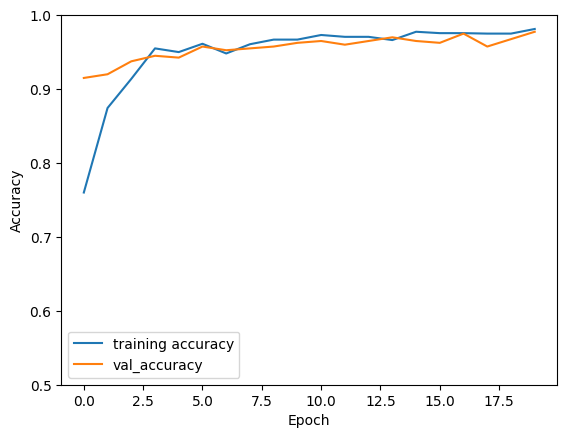

In [ ]:
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])

###Evaluación del modelo CNN de clasificación binaria

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Validation accuracy: {accuracy:.4f}")

363/363 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.9671 - loss: 0.1135
Validation accuracy: 0.9671


**Cáculamos las métricas de precisión, recall, F1-SCORE; para cada clase**

              precision    recall  f1-score   support

        Dark       0.99      0.96      0.98      7872
       Light       0.92      0.98      0.95      3722

    accuracy                           0.97     11594
   macro avg       0.96      0.97      0.96     11594
weighted avg       0.97      0.97      0.97     11594



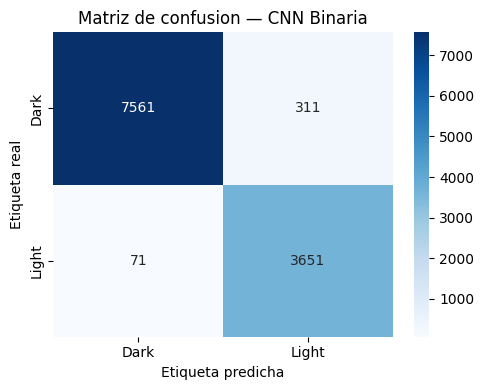

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Obtener predicciones: probabilidades -> etiquetas binarias
y_proba = model.predict(X_test, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)  # umbral de 0.5
#función de sklearn para obtener la precisión, recall y F1 score
print(classification_report(y_test, y_pred, target_names=['Dark', 'Light']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dark', 'Light'],
            yticklabels=['Dark', 'Light'])
plt.ylabel('Etiqueta real')
plt.xlabel('Etiqueta predicha')
plt.title('Matriz de confusion — CNN Binaria')
plt.tight_layout()
plt.show()

In [ ]:
print(y_proba.shape)
print(y_proba[0])
print(y_pred.shape)
print(y_pred[0])

(11594,)
0.99748385
(11594,)
1


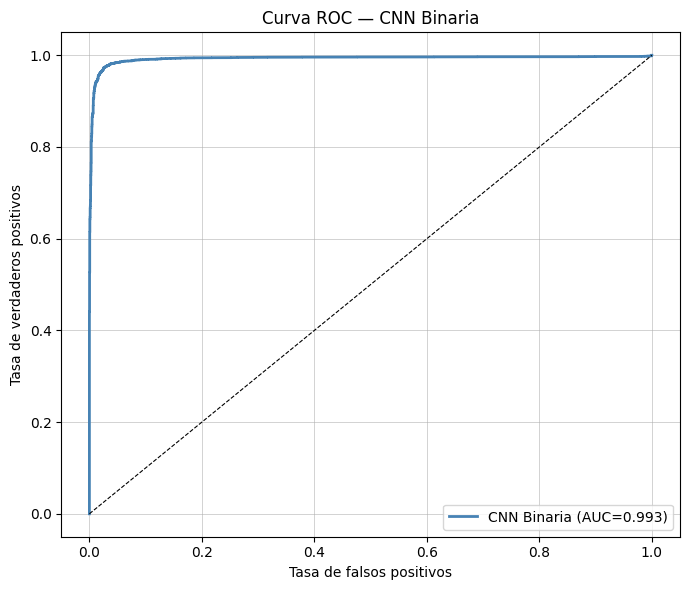

In [ ]:
from sklearn.metrics import roc_curve, auc

# Se usan probabilidades directamente, en lugar de etiquetas duras
# dark=anomalia=1, light=normal=0
y_scores_anomalia = 1 - y_proba #En el diseño del CNN, light=1|dark=0 => invertimos el score
fpr_cnn, tpr_cnn, thresholds = roc_curve(
    1 - y_test,           # dark=1, light=0
    y_scores_anomalia
)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

plt.figure(figsize=(7, 6))
plt.plot(fpr_cnn, tpr_cnn, color='steelblue',
         label=f'CNN Binaria (AUC={roc_auc_cnn:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC — CNN Binaria')
plt.legend()
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.show()

##AUTOENCODER

In [ ]:
from tensorflow.keras import Input
import matplotlib.ticker as ticker

In [ ]:
# ========================================
# ARQUITECTURA COMÚN DE LOS AUTOENCODERS
# ========================================

def build_autoencoder(input_len, latent_dim):
  """
    Autoencoder Con capas convolucionales 1D con bottleneck nombrado.
    input_len: número de muestras por traza. 1200
    latent_dim: dimensión del espacio latente
    return: autoencoder, encoder
  """

  inputs = Input(shape=(input_len, 1), name='encoder_input')

  # ENCODER
  x = layers.Conv1D(32, kernel_size=7, activation='relu', padding='same')(inputs)
  x = layers.MaxPooling1D(2)(x)
  x = layers.Conv1D(16, kernel_size=5, activation='relu', padding='same')(x)
  x = layers.MaxPooling1D(2)(x)
  x = layers.Conv1D(8,  kernel_size=3, activation='relu', padding='same')(x)
  x = layers.MaxPooling1D(2)(x)

  shape_before_flatten = x.shape[1:]  # (150, 8)

  x = layers.Flatten()(x)
  bottleneck = layers.Dense(latent_dim, activation='relu', name='bottleneck')(x)

  # --- DECODER ---
  x = layers.Dense(
      shape_before_flatten[0] * shape_before_flatten[1],  # 150 × 8 = 1200
      activation='relu'
  )(bottleneck)
  x = layers.Reshape(shape_before_flatten)(x)  # (150, 8)

  x = layers.Conv1DTranspose(8,  kernel_size=3, activation='relu', padding='same')(x)
  x = layers.UpSampling1D(2)(x)   # (300, 8)
  x = layers.Conv1DTranspose(16, kernel_size=5, activation='relu', padding='same')(x)
  x = layers.UpSampling1D(2)(x)   # (600, 16)
  x = layers.Conv1DTranspose(32, kernel_size=7, activation='relu', padding='same')(x)
  x = layers.UpSampling1D(2)(x)   # (1200, 32)

  # Capa de salida: vuelve a 1 canal
  outputs = layers.Conv1D(1, kernel_size=1, activation='linear',
                          padding='same', name='decoder_output')(x)  # (1200, 1)

  autoencoder = Model(inputs, outputs, name='autoencoder')
  autoencoder.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=5.2e-4),
      loss='mae')

  encoder = Model(inputs, bottleneck, name='encoder')

  return autoencoder, encoder

In [ ]:
autoencoder_light, encoder_light = build_autoencoder(1200, latent_dim=16)
autoencoder_dark,  encoder_dark  = build_autoencoder(1200, latent_dim=16)
autoencoder_light_dark,  encoder_both  = build_autoencoder(1200, latent_dim=16)

autoencoder_light.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 1200, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_45 (Conv1D)              │ (None, 1200, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_45 (MaxPooling1D) │ (None, 600, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_46 (Conv1D)              │ (None, 600, 16)        │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_46 (MaxPooling1D) │ (None, 300, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_47 (Conv1D)              │ (None, 300, 8)         │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_47 (MaxPooling1D) │ (None, 150, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │        19,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1200)           │        20,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_9 (Reshape)             │ (None, 150, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_27             │ (None, 150, 8)         │           200 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_27 (UpSampling1D) │ (None, 300, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_28             │ (None, 300, 16)        │           656 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_28 (UpSampling1D) │ (None, 600, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_29             │ (None, 600, 32)        │         3,616 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_29 (UpSampling1D) │ (None, 1200, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv1D)         │ (None, 1200, 1)        │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,345 (184.94 KB)

 Trainable params: 47,345 (184.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def recortar_pulsos(n_samples, light, dark):
  X_light = np.array([pulse[VENTANA_INI:VENTANA_FIN] for pulse in light[:n_samples]])
  X_dark  = np.array([pulse[VENTANA_INI:VENTANA_FIN] for pulse in dark[:n_samples]])
  return X_light, X_dark

In [ ]:
# ===============================
# FUNCIÓN DE NORMALIZACIÓN
# =============================

def normalizar(X_train, X_eval_list):
    """
    Normaliza el conjunto X_train con su propia media y
    desviación.
    Aplica los mismos parámetros a cada array en X_eval_list.
    Añade canal de dimensión.
    """
    mean = np.mean(X_train)
    std  = np.std(X_train)
    X_train_norm = ((X_train - mean) / std)[..., np.newaxis]
    X_eval_norm  = [((X - mean) / std)[..., np.newaxis] for X in X_eval_list]
    return X_train_norm, X_eval_norm, mean, std

### Autoencoder 1: Entrenado solo con pulsos LIGHT

In [ ]:
X_light, X_dark = recortar_pulsos(2000, LIGHT_PULSES, DARK_PULSES)

In [ ]:
# AUTOENCODER 1
# Normalización
X_light_norm, [X_dark_norm_for_light], mean_l, std_l = normalizar(
    X_light, [X_dark])

# Split train/val solo con light
X_l_train, X_l_val = train_test_split(X_light_norm, test_size=0.2,
    random_state=42)

print(f"Train light: {X_l_train.shape} | Val light: {X_l_val.shape}")

history_light = autoencoder_light.fit(
    X_l_train, X_l_train,
    validation_data=(X_l_val, X_l_val),  # solo light, mide convergencia
    epochs=20,
    batch_size=99,
    shuffle=True
)

Train light: (1600, 1200, 1) | Val light: (400, 1200, 1)
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 275ms/step - loss: 0.6691 - val_loss: 0.5937
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 316ms/step - loss: 0.5790 - val_loss: 0.5545
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - loss: 0.5475 - val_loss: 0.5293
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 242ms/step - loss: 0.5266 - val_loss: 0.5159
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 295ms/step - loss: 0.5181 - val_loss: 0.5093
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 248ms/step - loss: 0.5100 - val_loss: 0.5005
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 310ms/step - loss: 0.4986 - val_loss: 0.4859
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 248ms/step - loss: 0.4746 - val_loss: 0.4366
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 331ms/step - loss: 0.3611 - val_loss: 0.2656
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - loss: 0.2410 - val_loss: 0.2267
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 286ms/step - loss: 0.2196 - val_loss: 0.

### AUTOENCODER entrenado solo con pulsos Dark

In [ ]:
# =======================================
# Autoencoder 2 ENTRENADO SOLO CON DARK
# =======================================

X_dark_norm, [X_light_norm_for_dark], mean_d, std_d = normalizar(
    X_dark, [X_light])

X_d_train, X_d_val = train_test_split(X_dark_norm, test_size=0.2, random_state=42)

print(f"Train dark: {X_d_train.shape} | Val dark: {X_d_val.shape}")

history_dark = autoencoder_dark.fit(
    X_d_train, X_d_train,
    validation_data=(X_d_val, X_d_val),  # solo dark, mide convergencia
    epochs=20,
    batch_size=99,
    shuffle=True
)

Train dark: (1600, 1200, 1) | Val dark: (400, 1200, 1)
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 257ms/step - loss: 0.7532 - val_loss: 0.7273
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - loss: 0.6074 - val_loss: 0.4734
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 307ms/step - loss: 0.4134 - val_loss: 0.3208
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - loss: 0.2569 - val_loss: 0.1890
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - loss: 0.1725 - val_loss: 0.1519
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 321ms/step - loss: 0.1453 - val_loss: 0.1360
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 337ms/step - loss: 0.1323 - val_loss: 0.1290
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - loss: 0.1264 - val_loss: 0.1232
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 310ms/step - loss: 0.1211 - val_loss: 0.1200
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - loss: 0.1174 - val_loss: 0.1159
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 220ms/step - loss: 0.1139 - val_loss: 0.11

### Autoencoder 3 entrenado con pulsos Light y Dark

Este autoencoder se entrena con los dos tipos de pulsos, al sumar ambos 2000 light + 2000 dark obtenemos que el
autoencoder 3 se entrena con 4000 pulsos, el doble que los individuales. Se perdería la objetividad del experimento
ya que uno de los modelos se entrena con más datos.
solucion propuesta: de los 2000 pulsos de cada tipo elegiremos los 1000 primeros de cada tipo

In [ ]:
X_light =  X_light[:1000]
X_dark  =  X_dark[:1000]

In [ ]:
# ==========================
# AUTOENCODER 3: LIGHT + DARK
# ==========================
#se usan los mismos pulsos seleccionados en los autoencoders anteriores para que la comparación de los modelos tenga sentido
X_both = np.concatenate([X_light, X_dark], axis=0) #light + dark
# Normalización con parámetros del conjunto combinado
X_both_norm, [X_light_for_both, X_dark_for_both], mean_b, std_b = normalizar(X_both, [X_light, X_dark])
# (guardamos mean_b y std_b para normalizar cualquier dato nuevo)

X_b_train, X_b_val = train_test_split(X_both_norm, test_size=0.2,
                                       random_state=42, shuffle=True)

print(f"Train both: {X_b_train.shape} | Val both: {X_b_val.shape}")


Train both: (1600, 1200, 1) | Val both: (400, 1200, 1)


In [ ]:
history_light_dark = autoencoder_light_dark.fit(
    X_b_train, X_b_train,
    validation_data=(X_b_val, X_b_val),
    epochs=35,
    batch_size=99,
    shuffle=True
)

Epoch 1/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 304ms/step - loss: 0.7281 - val_loss: 0.6932
Epoch 2/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 659ms/step - loss: 0.5703 - val_loss: 0.3407
Epoch 3/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 451ms/step - loss: 0.2863 - val_loss: 0.2313
Epoch 4/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step - loss: 0.2210 - val_loss: 0.2005
Epoch 5/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - loss: 0.1931 - val_loss: 0.1778
Epoch 6/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 319ms/step - loss: 0.1705 - val_loss: 0.1587
Epoch 7/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 246ms/step - loss: 0.1553 - val_loss: 0.1479
Epoch 8/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - loss: 0.1459 - val_loss: 0.1412
Epoch 9/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - loss: 0.1409 - val_loss: 0.1380
Epoch 10/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step - loss: 0.1378 - val_loss: 0.1347
Epoch 11/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 522ms/step - loss: 0.1348 - val_loss: 0.1320
Epoch 12/35
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 368ms/ste

**Conclusiones del entrenamiento de las 3 variantes de Autoencoder.**
El primer Autoencdoer **solo** se ha entrenado con pulsos Light

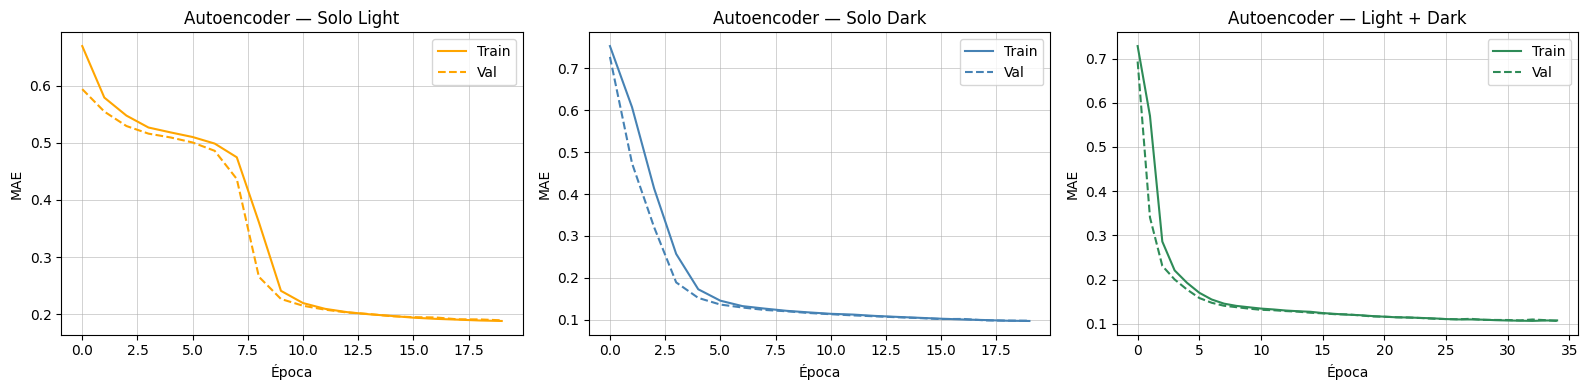

In [ ]:
# CURVAS DE PÉRDIDA PARA CADA AUTOENCODER
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
configs = [
    (history_light, 'Autoencoder — Solo Light',     'orange'),
    (history_dark,  'Autoencoder — Solo Dark',      'steelblue'),
    (history_light_dark,  'Autoencoder — Light + Dark',   'seagreen'),]

for ax, (hist, title, color) in zip(axes, configs):
    ax.plot(hist.history['loss'],     color=color, label='Train')
    ax.plot(hist.history['val_loss'], color=color, linestyle='--', label='Val')
    ax.set_title(title)
    ax.set_xlabel('Época')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True, linewidth=0.4)

plt.tight_layout()
#plt.savefig("curvas_perdida_autoencoders.png", dpi=120)
plt.show()

**Conclusiones de las gráficas:**

  En la primera gráfica se ve que la función de pérdida para los datos de validación es bastante pequeño Este primer modelo se entrenó SOLO con pulsos Light, lo que nos está diciendo es que está reconstruyendo bastante bien los pulsos de luz. No parece que haya overfitting.

  En la segunda gráfica, tenemos un comportamiento bastante similar a la primera. El segundo modelo de autoencoder ha sido entrenado solo conk pulsos DARK, es decir, este modelo está reconstruyedo con bastante precisión los pulsos DARK. Destaca que la función de pérdida de validación cae más rápido que la 'train loss'. Esto puede ser porque el conjunto de validación tiene una distribución más homogenea que el del conjunto de entrenamiento simplemente por azar en la división. Hay que tener en cuenta que el conjunto de pulsos dark tiene más dispersión en los valores que los light.

  Por último, en la tercera gráfica, vemos que las funciones de pérdida para entrenamiento y validación NO convergen; además el MAE es mayor que los anteriores modelos.
  
  curvas_perdida_autoencoder_v1.png

  Repetiremos el experimento subiendo el nº de épocas a 35 y observamos que las funciones se estabilizan.


### EVALUCACIÓN FINAL: Error de reconstrucción por cada clase

In [ ]:
# ============================================================
# EVALUACIÓN FINAL: ERROR DE RECONSTRUCCIÓN POR CLASE
# ============================================================

def error_reconstruccion(modelo, X):
    """MAE por muestra."""
    X_pred = modelo.predict(X, verbose=0)
    return np.mean(np.abs(X - X_pred), axis=(1, 2)), X_pred

ValueError: x must have 2 or fewer dimensions

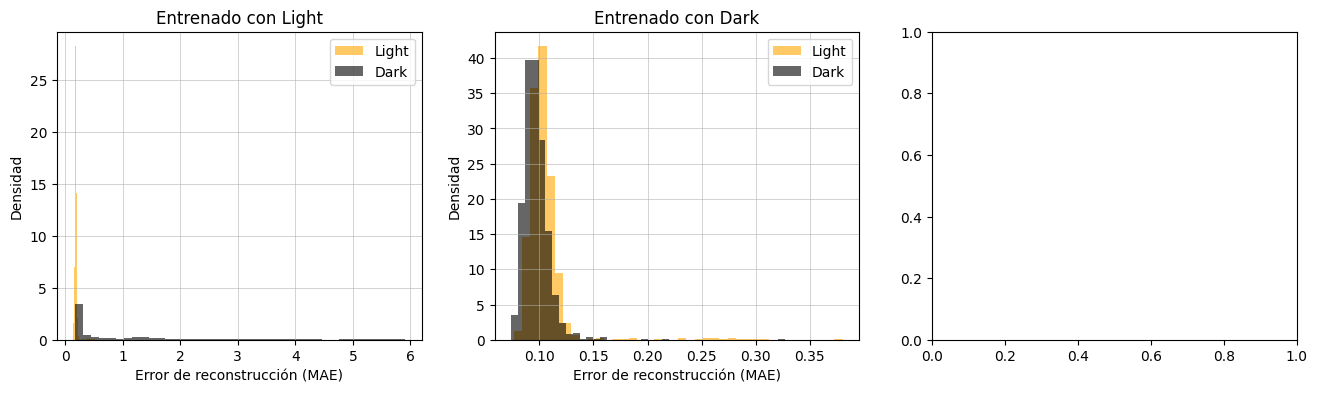

In [ ]:
# --- Autoencoder light ---
err_light_on_light, X_light_pred_onLight = error_reconstruccion(autoencoder_light, X_light_norm)
err_light_on_dark, X_dark_pred_onLight  = error_reconstruccion(autoencoder_light, X_dark_norm_for_light) #pulsos dark normalizados obtenidos de la normalizacion de los pulsos light

# --- Autoencoderante dark ---
err_dark_on_dark, X_dark_pred_onDark   = error_reconstruccion(autoencoder_dark, X_dark_norm)
err_dark_on_light, Xlight_pred_onDark  = error_reconstruccion(autoencoder_dark, X_light_norm_for_dark) #pulsos light normalizados obtenidoa de la normalizacion de los pulsos dark

# --- Autoencoder ambos pulsos (normalizamos pulsos light y dark)
#X_light_for_both = ((X_light - mean_b) / std_b)[..., np.newaxis]
#X_dark_for_both  = ((X_dark  - mean_b) / std_b)[..., np.newaxis]
err_both_on_light = error_reconstruccion(autoencoder_light_dark, X_light_for_both)
err_both_on_dark  = error_reconstruccion(autoencoder_light_dark, X_dark_for_both)

# Distribuciones de error
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
configs_eval = [
    (err_light_on_light, err_light_on_dark, 'Entrenado con Light', 'orange', 'black'),
    (err_dark_on_light,  err_dark_on_dark, 'Entrenado con Dark',  'orange', 'black'),
    (err_both_on_light,  err_both_on_dark, 'Entrenado con Light+Dark', 'orange', 'black')]

for ax, (err_l, err_d, title, c_l, c_d) in zip(axes, configs_eval):
    ax.hist(err_l, bins=40, alpha=0.6, color=c_l, label='Light', density=True)
    ax.hist(err_d, bins=40, alpha=0.6, color=c_d, label='Dark',  density=True)
    ax.set_title(title)
    ax.set_xlabel('Error de reconstrucción (MAE)')
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.grid(True, linewidth=0.4)

plt.suptitle('Distribución del error de reconstrucción por variante', y=1.02)
plt.tight_layout()
#plt.savefig("errores_reconstruccion.png", dpi=120)
plt.show()

In [ ]:
# Verificar que la normalización es correcta para cada variante
print("Media X_light_norm:", np.mean(X_light_norm))  # debe ser ~0
print("Std  X_light_norm:", np.std(X_light_norm))    # debe ser ~1

# Verificar que el error se calcula sobre datos normalizados
# y no sobre datos en mV sin normalizar
print("Rango X_light_norm:", X_light_norm.min(), X_light_norm.max())
print("Rango X_dark_norm:",  X_dark_norm_for_light.min(),
                              X_dark_norm_for_light.max())

Media X_light_norm: 1.8284633066893244e-17
Std  X_light_norm: 0.9999999999999996
Rango X_light_norm: -6.2075704779674705 2.382512969491706
Rango X_dark_norm: -9.548646946784755 2.0835745485975283


In [ ]:
# =============================================
# SCATTER PLOTS DEL ESPACIO LATENTE (PCA 2D)
# =============================================

def scatter_latente(encoder, X_light, X_dark, titulo):
    z_light = encoder.predict(X_light, verbose=0)
    z_dark  = encoder.predict(X_dark,  verbose=0)

    z_all = np.vstack([z_light, z_dark])
    pca   = PCA(n_components=2)
    z_2d  = pca.fit_transform(z_all)

    varianza = pca.explained_variance_ratio_

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(z_2d[:len(z_light), 0], z_2d[:len(z_light), 1],
               c='orange', alpha=0.5, s=12, label='Light', zorder=3)
    ax.scatter(z_2d[len(z_light):, 0], z_2d[len(z_light):, 1],
               c='black',  alpha=0.5, s=12, label='Dark', zorder=3)

    ax.set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)')
    ax.set_title(titulo)
    ax.legend()

    # Cuadrícula más densa
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))

    ax.grid(which='major', color='gray',  linestyle='--', linewidth=0.5, zorder=0)
    ax.grid(which='minor', color='gray',  linestyle=':',  linewidth=0.3, zorder=0)

    plt.tight_layout()
    plt.savefig(f"scatter_{titulo.replace(' ', '_')}.png", dpi=120)
    plt.show()

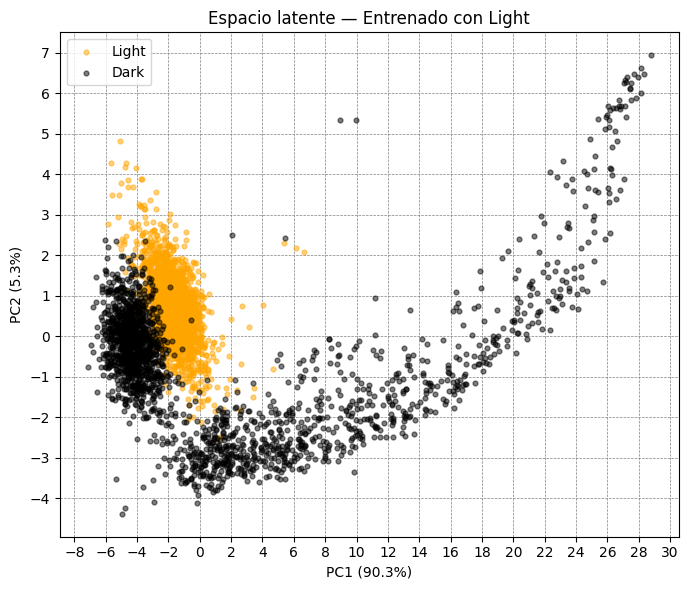

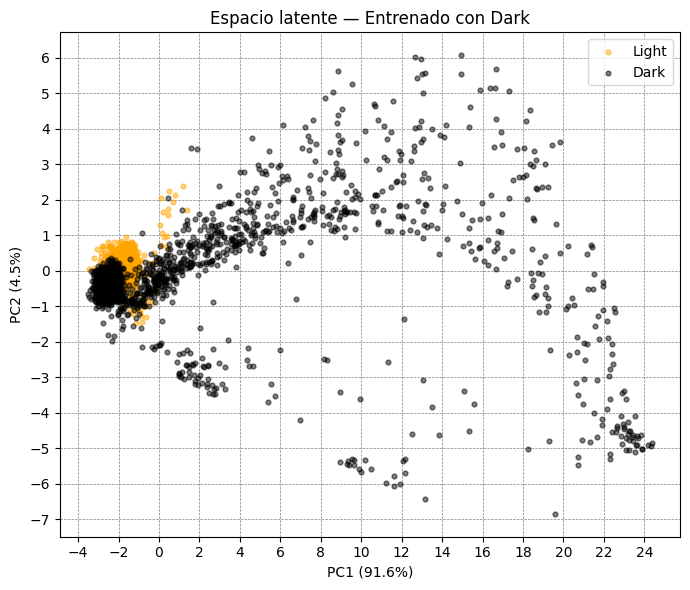

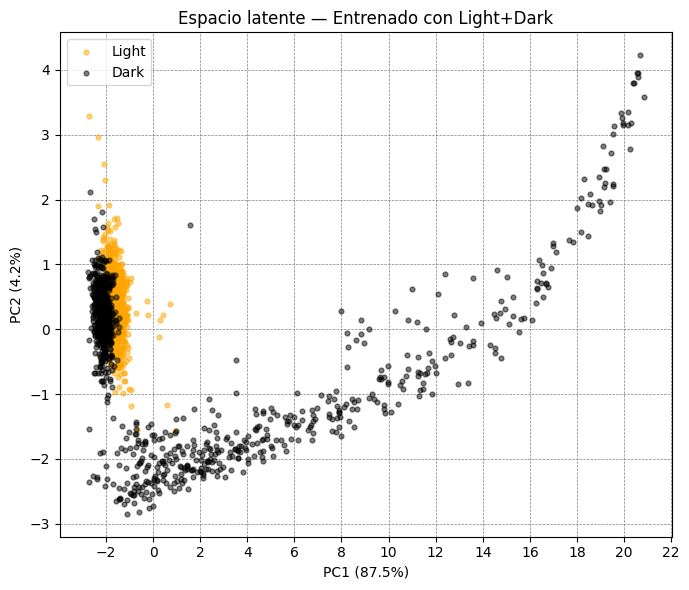

In [ ]:
# Scatter del encoder entrenado con light (evaluado con light y dark)
scatter_latente(encoder_light,
                X_light_norm, X_dark_norm_for_light,
                'Espacio latente — Entrenado con Light')

# Scatter del encoder entrenado con dark (evaluado con dark y light)
scatter_latente(encoder_dark,
                X_light_norm_for_dark, X_dark_norm,
                'Espacio latente — Entrenado con Dark')

# Scatter del encoder entrenado con ambos
scatter_latente(encoder_both,
                X_light_for_both, X_dark_for_both,
                'Espacio latente — Entrenado con Light+Dark')

La primera imagen representa el espacio latente que se obtiene del primer Autoencoder entrenado solo con pulsos light y

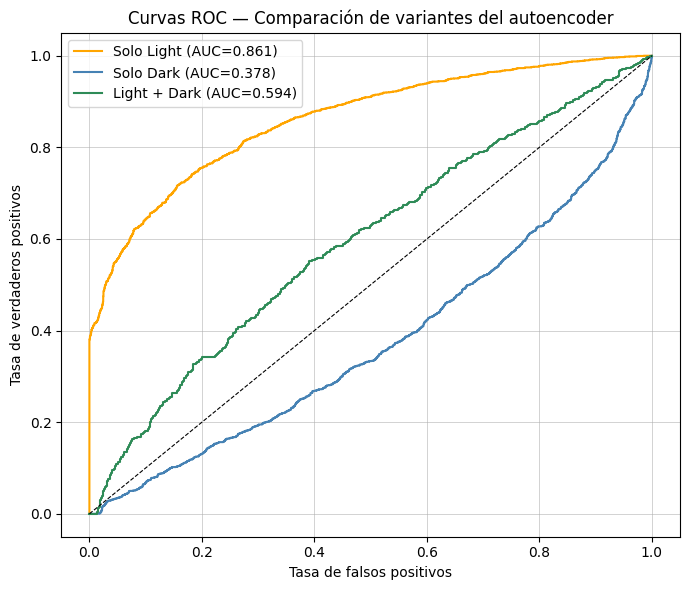

In [ ]:
# =========================================================
# CURVAS ROC COMPARATIVAS DE LAS 3 VARIANTES DE AUTOENCODER
# =========================================================

from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

configs_roc = [
    (err_light_on_light, err_light_on_dark, 'Solo Light',     'orange'),
    (err_dark_on_light,  err_dark_on_dark,  'Solo Dark',      'steelblue'),
    (err_both_on_light,  err_both_on_dark,  'Light + Dark',   'seagreen'),
]

for err_l, err_d, label, color in configs_roc:
    # Light=0 (normal), Dark=1 (anomalía)
    scores = np.concatenate([err_l, err_d])
    labels = np.concatenate([np.zeros(len(err_l)), np.ones(len(err_d))])
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, label=f'{label} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curvas ROC — Comparación de variantes del autoencoder')
ax.legend()
ax.grid(True, linewidth=0.4)
plt.tight_layout()
plt.savefig("roc_autoencoders.png", dpi=120)
plt.show()

In [ ]:
# Imprime las entradas reales que usas en cada caso
print("=== Variante LIGHT ===")
print("  Eval light - mean:", np.mean(X_light_norm),
      "std:", np.std(X_light_norm))
print("  Eval dark  - mean:", np.mean(X_dark_norm_for_light),
      "std:", np.std(X_dark_norm_for_light))

print("=== Variante DARK ===")
print("  Eval light - mean:", np.mean(X_light_norm_for_dark),
      "std:", np.std(X_light_norm_for_dark))
print("  Eval dark  - mean:", np.mean(X_dark_norm),
      "std:", np.std(X_dark_norm))

print("=== Variante BOTH ===")
print("  Eval light - mean:", np.mean(X_light_for_both),
      "std:", np.std(X_light_for_both))
print("  Eval dark  - mean:", np.mean(X_dark_for_both),
      "std:", np.std(X_dark_for_both))

=== Variante LIGHT ===
  Eval light - mean: 1.8284633066893244e-17 std: 0.9999999999999996
  Eval dark  - mean: -1.0450789526589133 std: 2.239633945500239
=== Variante DARK ===
  Eval light - mean: 0.4666293591230086 std: 0.44650153745398824
  Eval dark  - mean: -2.8516448461838687e-16 std: 1.0
=== Variante BOTH ===
  Eval light - mean: 0.2916565052571278 std: 0.5548987606530751
  Eval dark  - mean: -0.2916565052571279 std: 1.2336775637532191


## Modelo Mixto Gaussiano (GMM)

Para el modelo GMM debemos extraer un vector algunas características de los pulsos. No trabaja con la traza cruda como en los modelos anteriores.

In [ ]:
# ========================================
# EXTRACCIÓN DE CARACTERÍSTICAS POR TRAZA
# ========================================

from scipy.stats import skew, kurtosis

def extraer_caracteristicas(pulsos):
    """
    Extrae un vector de 8 características por traza.
    pulsos: array (N, 1200) en mV, ya con offset eliminado.
    """
    features = []
    for traza in pulsos:
        # Amplitud del pico
        v_min = np.min(traza)

        # Posición temporal del pico (en muestras)
        idx_min = np.argmin(traza)

        # Estimación de tau_rise: muestras desde el 10% al 90% de la amplitud
        # en el flanco de bajada (antes del mínimo)
        umbral_10 = 0.1 * v_min
        umbral_90 = 0.9 * v_min
        flanco_bajada = traza[:idx_min]
        idx_10 = next((i for i, v in enumerate(flanco_bajada) if v < umbral_10),
                      idx_min)
        idx_90 = next((i for i, v in enumerate(flanco_bajada) if v < umbral_90),
                      idx_min)
        tau_rise = idx_90 - idx_10  # en muestras (1 muestra = 0.02 µs)

        # Estimación de tau_decay: muestras desde el mínimo hasta recuperar el 90%
        flanco_subida = traza[idx_min:]
        umbral_rec = 0.1 * v_min  # 90% recuperado = queda 10% de la amplitud
        idx_rec = next((i for i, v in enumerate(flanco_subida) if v > umbral_rec),
                       len(flanco_subida) - 1)
        tau_decay = idx_rec  # en muestras

        # Estadísticos del baseline (primeras 100 muestras)
        baseline = traza[:100]
        baseline_std = np.std(baseline)

        # Energía total del pulso (integral aproximada)
        energia = np.trapz(np.abs(traza))

        # Asimetría y curtosis de la traza completa
        asimetria = skew(traza)
        curtosis_val = kurtosis(traza)

        features.append([
            v_min,          # amplitud del pico (mV)
            tau_rise,       # tiempo de subida (muestras)
            tau_decay,      # tiempo de bajada (muestras)
            baseline_std,   # ruido de baseline (mV)
            energia,        # energia del pulso
            asimetria,      # asimetria de la distribucion de voltajes
            curtosis_val,   # curtosis
            idx_min,        # posicion del pico en la ventana
        ])

    return np.array(features)  # (N, 8)

light_pulses = np.array([pulse[VENTANA_INI:VENTANA_FIN] for pulse in LIGHT_PULSES])
dark_pulses  = np.array([pulse[VENTANA_INI:VENTANA_FIN] for pulse in DARK_PULSES])

# Aplicar sobre los conjuntos ya recortados con ventana [1200, 2500]
F_light = extraer_caracteristicas(light_pulses)  # (N_light, 8)
F_dark  = extraer_caracteristicas(dark_pulses)   # (N_dark,  8)

print(f"Features light: {F_light.shape}")
print(f"Features dark:  {F_dark.shape}")

/tmp/ipykernel_6778/522223389.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energia = np.trapz(np.abs(traza))


Features light: (4722, 8)
Features dark:  (8872, 8)


In [ ]:
print(f"Features light: {F_light.shape}")
print(f"Features dark:  {F_dark.shape}")

Features light: (4722, 8)
Features dark:  (8872, 8)


In [ ]:
# =================================
# NORMALIZACIÓN DE CARACTERÍSTICAS
# =================================
# Igual que con el autoencoder: normalizar con parámetros
# del conjunto de entrenamiento únicamente

from sklearn.preprocessing import StandardScaler

n_samples = 1000
np.random.seed(42)

idx_sel_light = np.random.choice(len(F_light), n_samples, replace=False)
idx_sel_dark  = np.random.choice(len(F_dark),  n_samples, replace=False)

F_light_sel = F_light[idx_sel_light]  # (1000, 8)
F_dark_sel  = F_dark[idx_sel_dark]    # (1000, 8)

# Normalizar con parámetros del conjunto light (igual que autoencoder solo light)
scaler = StandardScaler()
F_light_norm = scaler.fit_transform(F_light_sel)
F_dark_norm  = scaler.transform(F_dark_sel)  # mismos parámetros

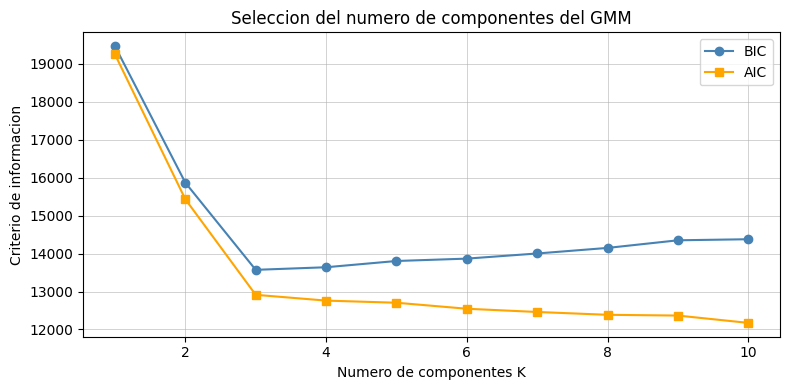

K optimo segun BIC: 3


In [ ]:
# =======================================
# SELECCIÓN DEL NÚMERO DE COMPONENTES K
# =======================================
# Se evalúa el BIC (Bayesian Information Criterion) para
# distintos valores de K. El K óptimo minimiza el BIC.

from sklearn.mixture import GaussianMixture

bic_scores = []
aic_scores = []
K_range = range(1, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k,
                          covariance_type='full',
                          random_state=42,
                          max_iter=200)
    gmm.fit(F_light_norm)
    bic_scores.append(gmm.bic(F_light_norm))
    aic_scores.append(gmm.aic(F_light_norm))

plt.figure(figsize=(8, 4))
plt.plot(K_range, bic_scores, 'o-', label='BIC', color='steelblue')
plt.plot(K_range, aic_scores, 's-', label='AIC', color='orange')
plt.xlabel('Nº de componentes K')
plt.ylabel('Criterio de información')
plt.title('Selección del numero de componentes del GMM')
plt.legend()
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.savefig("gmm_bic_aic.png", dpi=120)
plt.show()

k_optimo = K_range[np.argmin(bic_scores)]
print(f"K optimo segun BIC: {k_optimo}")

In [ ]:
# ========================
# ENTRENAMIENTO DEL GMM
# ========================

gmm_light = GaussianMixture(
    n_components    = k_optimo,
    covariance_type = 'full',   # matriz de covarianza completa
    random_state    = 42,
    max_iter        = 200,
    n_init          = 5         # 5 inicializaciones, se queda con la mejor
)

gmm_light.fit(F_light_norm)
print(f"Convergencia: {gmm_light.converged_}")
print(f"Iteraciones:  {gmm_light.n_iter_}")

Convergencia: True
Iteraciones:  8


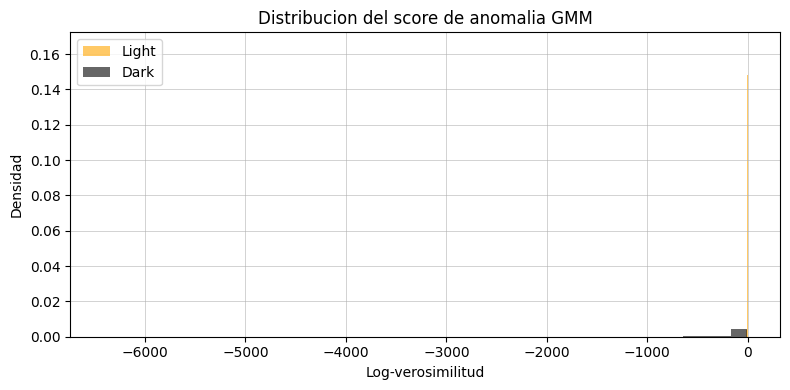

In [ ]:
# ============================================================
# EVALUACIÓN: LOG-VEROSIMILITUD COMO SCORE DE ANOMALÍA
# ============================================================
# Score alto (menos negativo) = el punto es probable bajo el modelo = luz
# Score bajo (muy negativo)   = el punto es improbable = anomalía = dark

log_prob_light = gmm_light.score_samples(F_light_norm)
log_prob_dark  = gmm_light.score_samples(F_dark_norm)

# Distribución de scores
plt.figure(figsize=(8, 4))
plt.hist(log_prob_light, bins=40, alpha=0.6,
         color='orange', density=True, label='Light')
plt.hist(log_prob_dark,  bins=40, alpha=0.6,
         color='black',  density=True, label='Dark')
plt.xlabel('Log-verosimilitud')
plt.ylabel('Densidad')
plt.title('Distribucion del score de anomalia GMM')
plt.legend()
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.savefig("gmm_scores.png", dpi=120)
plt.show()

In [ ]:
import pandas as pd

nombres = ['v_min', 'tau_rise', 'tau_decay', 'baseline_std',
           'energia', 'asimetria', 'curtosis', 'idx_min']

df_light = pd.DataFrame(F_light_sel, columns=nombres)
df_dark  = pd.DataFrame(F_dark_sel,  columns=nombres)

print("=== LIGHT (sin normalizar) ===")
print(df_light.describe().round(2))
print("\n=== DARK (sin normalizar) ===")
print(df_dark.describe().round(2))

# Ver si hay valores extremos o NaN
print("\n=== NaN en light:", df_light.isna().sum().sum())
print("=== NaN en dark: ", df_dark.isna().sum().sum())
print("=== Inf en light:", np.isinf(F_light_sel).sum())
print("=== Inf en dark: ", np.isinf(F_dark_sel).sum())

=== LIGHT (sin normalizar) ===
         v_min  tau_rise  tau_decay  baseline_std  energia  asimetria  \
count  1000.00   1000.00    1000.00        1000.0  1000.00    1000.00   
mean     -0.02     58.10     188.84           0.0     3.44      -1.85   
std       0.00     63.83      32.87           0.0     0.40       0.17   
min      -0.02     10.00     102.00           0.0     2.65      -2.29   
25%      -0.02     17.00     166.00           0.0     3.18      -1.96   
50%      -0.02     21.00     186.00           0.0     3.38      -1.86   
75%      -0.02     92.00     210.00           0.0     3.61      -1.75   
max      -0.01    266.00     344.00           0.0     5.99      -0.84   

       curtosis  idx_min  
count   1000.00  1000.00  
mean       2.91   225.53  
std        0.70    41.82  
min       -0.41   202.00  
25%        2.48   217.00  
50%        2.95   222.00  
75%        3.37   227.00  
max        5.08  1075.00  

=== DARK (sin normalizar) ===
         v_min  tau_rise  tau_decay  

## Isolation forest como detector de anomalías.



In [ ]:
from sklearn.ensemble import IsolationForest

# ── Preparación de datos ─────────────────────────────
# Se reutilizan las trazas ya recortadas y seleccionadas de secciones anteriores.
# Shape esperada: (1000, 1200) para cada conjunto, SIN la dimensión de canal.

X_light_if = X_light  # (1000, 1200)
X_dark_if  = X_dark   # (1000, 1200)

# Normalización con parámetros del conjunto light (mismo criterio que autoencoder)
mean_if = np.mean(X_light_if)
std_if  = np.std(X_light_if)

X_light_if_norm = (X_light_if - mean_if) / std_if  # (1000, 1200)
X_dark_if_norm  = (X_dark_if  - mean_if) / std_if  # (1000, 1200)

print(f"Shape light para IF: {X_light_if_norm.shape}")
print(f"Shape dark para IF:  {X_dark_if_norm.shape}")

Shape light para IF: (1000, 1200)
Shape dark para IF:  (1000, 1200)


In [ ]:
# ===================== Entrenamiento  ===============================
# Se entrena SOLO con pulsos de luz, igual que el autoencoder entrenado solo con pulsos light.
# contamination: fracción esperada de anomalías en el conjunto de entrenamiento.
# Como entrenamos solo con luz, ponemos un valor bajo (0.05 = 5%).

isolation_forest = IsolationForest(
    n_estimators  = 100,    # número de árboles de aislamiento
    max_samples   = 'auto', # muestras por árbol (por defecto min(256, N))
    contamination = 0.05,   # fracción esperada de anomalías en train
    random_state  = 42,
    n_jobs        = -1      # usar todos los cores disponibles
)

isolation_forest.fit(X_light_if_norm)
print("Entrenamiento completado.")

Entrenamiento completado.


In [ ]:
# ── Scores de anomalía ────────────────────────────────────────────────────
# score_samples devuelve el negative average path length.
# Valores más NEGATIVOS = más anómalos.
# Para ROC invertimos el signo: score alto = anomalía = dark.

scores_light = isolation_forest.score_samples(X_light_if_norm)
scores_dark  = isolation_forest.score_samples(X_dark_if_norm)

print(f"Score medio light: {np.mean(scores_light):.4f} ± {np.std(scores_light):.4f}")
print(f"Score medio dark:  {np.mean(scores_dark):.4f} ± {np.std(scores_dark):.4f}")

Score medio light: -0.4172 ± 0.0302
Score medio dark:  -0.5791 ± 0.1439


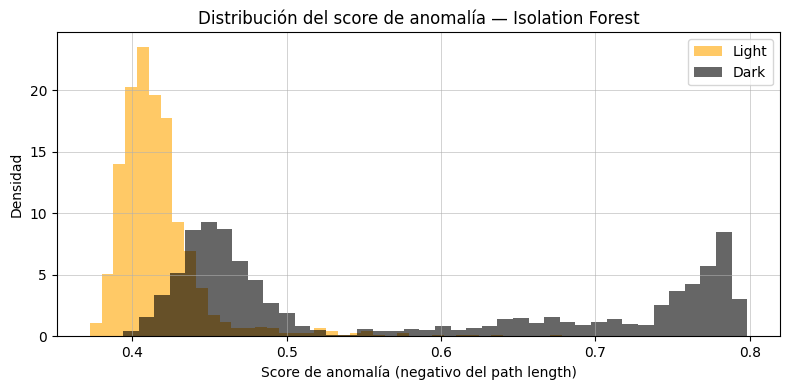

In [ ]:
# ── Distribución de scores ────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(-scores_light, bins=40, alpha=0.6,
         color='orange', density=True, label='Light')
plt.hist(-scores_dark,  bins=40, alpha=0.6,
         color='black',  density=True, label='Dark')
plt.xlabel('Score de anomalía (negativo del path length)')
plt.ylabel('Densidad')
plt.title('Distribución del score de anomalía — Isolation Forest')
plt.legend()
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.savefig("if_scores.png", dpi=120)
plt.show()

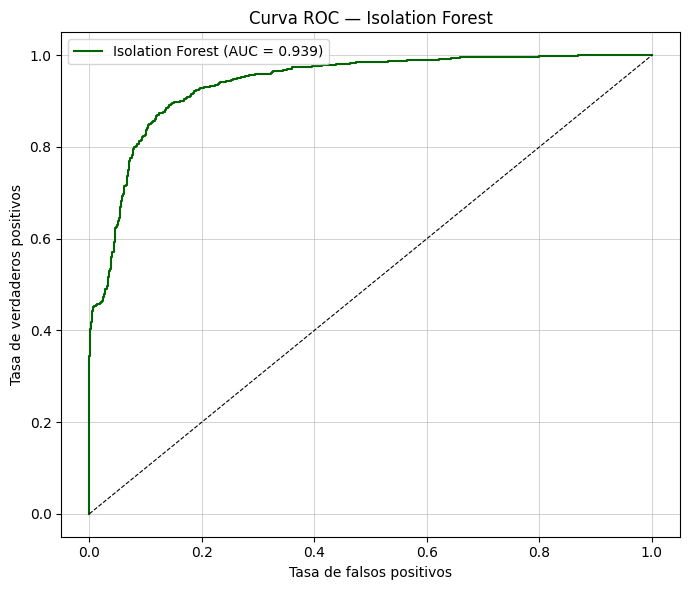

Isolation Forest AUC: 0.9386


In [ ]:
# ── Curva ROC y AUC ───────────────────────────────────────────────────────
# Dark = anomalía = etiqueta 1
# Light = normal  = etiqueta 0
# Usamos -scores porque score más negativo = más anómalo

scores_all = np.concatenate([-scores_light, -scores_dark])
labels_all = np.concatenate([
    np.zeros(len(scores_light)),  # light = 0 (normal)
    np.ones(len(scores_dark))     # dark  = 1 (anomalía)
])

fpr, tpr, thresholds = roc_curve(labels_all, scores_all)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkgreen',
         label=f'Isolation Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC — Isolation Forest')
plt.legend()
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.savefig("if_roc.png", dpi=120)
plt.show()

print(f"Isolation Forest AUC: {roc_auc:.4f}")

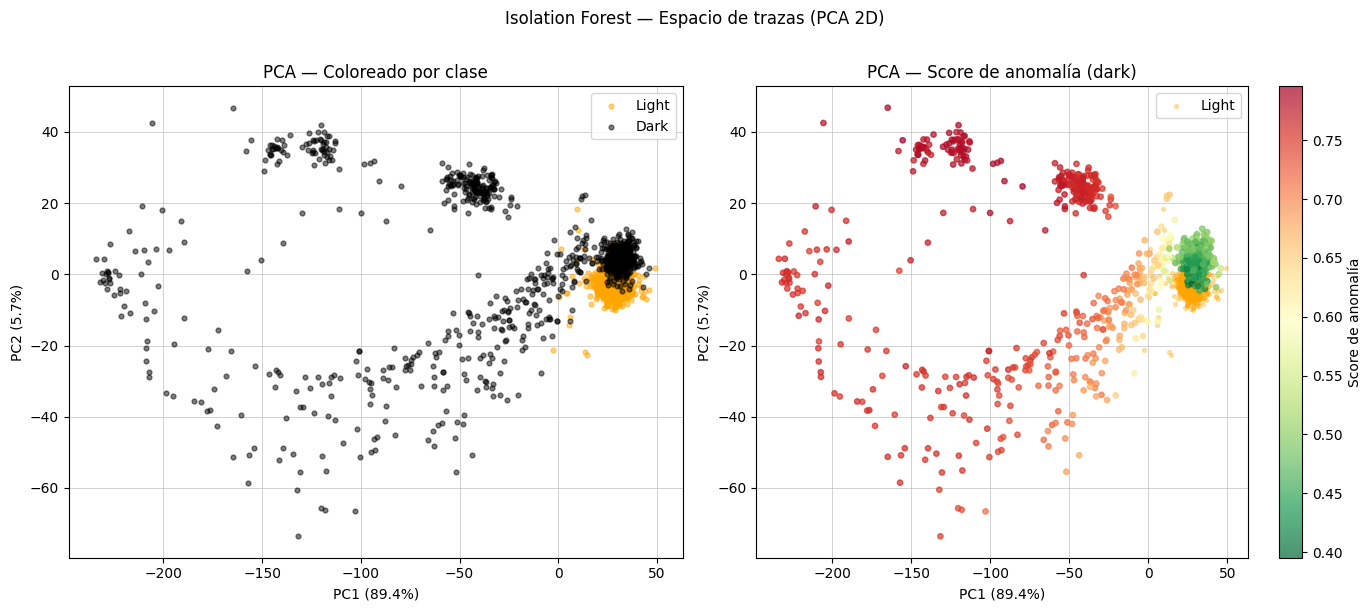

In [ ]:
# ── Scatter plot PCA del espacio de trazas ────────────────────────────────
# A diferencia del GMM, aquí el PCA opera sobre las trazas directamente,
# no sobre un vector de características extraídas manualmente.

pca = PCA(n_components=2)
X_all_2d = pca.fit_transform(
    np.vstack([X_light_if_norm, X_dark_if_norm])
)
varianza = pca.explained_variance_ratio_

# Score de anomalía como color continuo para los dark
scores_dark_color = -scores_dark  # más alto = más anómalo

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: coloreado por clase
axes[0].scatter(X_all_2d[:len(X_light_if_norm), 0],
                X_all_2d[:len(X_light_if_norm), 1],
                c='orange', alpha=0.5, s=12, label='Light', zorder=3)
axes[0].scatter(X_all_2d[len(X_light_if_norm):, 0],
                X_all_2d[len(X_light_if_norm):, 1],
                c='black', alpha=0.5, s=12, label='Dark', zorder=3)
axes[0].set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)')
axes[0].set_title('PCA — Coloreado por clase')
axes[0].legend()
axes[0].grid(True, linewidth=0.4)

# Panel derecho: coloreado por score de anomalía (solo dark)
sc = axes[1].scatter(
    X_all_2d[len(X_light_if_norm):, 0],
    X_all_2d[len(X_light_if_norm):, 1],
    c=scores_dark_color, cmap='RdYlGn_r',
    alpha=0.7, s=15, zorder=3
)
axes[1].scatter(X_all_2d[:len(X_light_if_norm), 0],
                X_all_2d[:len(X_light_if_norm), 1],
                c='orange', alpha=0.3, s=8, label='Light', zorder=2)
plt.colorbar(sc, ax=axes[1], label='Score de anomalía')
axes[1].set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)')
axes[1].set_title('PCA — Score de anomalía (dark)')
axes[1].legend()
axes[1].grid(True, linewidth=0.4)

plt.suptitle('Isolation Forest — Espacio de trazas (PCA 2D)', y=1.01)
plt.tight_layout()
plt.savefig("if_scatter.png", dpi=120)
plt.show()

### CNN de regresión

La otra alternativa que se sugiere en el artículo, es usar la CNN como modelo de regresión. En este caso, en lugar de calsificar el pulso como Light o Dark (salida binaria, 1 ó 0). El modelo tratará de predecir la engergía que tiene un pulso de Light (salida continua, un número). La detección de fondo se hace indirectamente, si el modelo predice bien la energía de un pulso de luz es porque se parece a la señal. Si la predicción es mala, es porque la morfología del pulso es diferente, Fondo.

Para la regresión debemos elegir que característica es la que se tratará de rpedecir (el target). El artículo menciona directamente el Vmin y el FFT.

Sin embargo, como en el pipeline no se ha implementado el ajuste en frecuencia, la alternativa directa es usar el mínimo de voltaje de la traza (V_min), que es el valor del pico del pulso en dominio temporal y es proporcional a la energía absorbida.

Rango V_min light: -0.0277 a -0.0123 V
Rango V_min dark:  -0.0421 a -0.0101 V


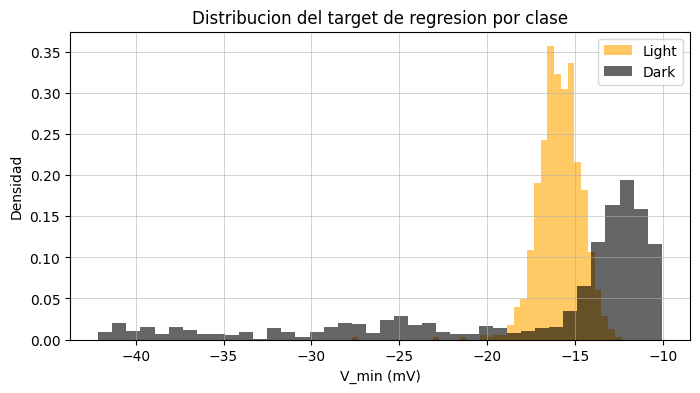

In [ ]:
# ==========================================
# PREPARACIÓN DEL TARGET DE REGRESIÓN (Vmin)
# ==========================================

# El target es el mínimo de cada traza (proporcional a la energía)
# Shape X_light, X_dark: (N, 1200) en V, con offset eliminado

y_light_reg = np.min(X_light, axis=1)  # (N,) valores negativos en V
y_dark_reg  = np.min(X_dark,  axis=1)  # (N,) valores negativos en V

print(f"Rango V_min light: {y_light_reg.min():.4f} a {y_light_reg.max():.4f} V")
print(f"Rango V_min dark:  {y_dark_reg.min():.4f} a {y_dark_reg.max():.4f} V")

# Visualizar distribuciones del target
plt.figure(figsize=(8, 4))
plt.hist(y_light_reg * 1000, bins=40, alpha=0.6,
         color='orange', density=True, label='Light')
plt.hist(y_dark_reg  * 1000, bins=40, alpha=0.6,
         color='black',  density=True, label='Dark')
plt.xlabel('V_min (mV)')
plt.ylabel('Densidad')
plt.title('Distribucion del target de regresion por clase')
plt.legend()
plt.grid(True, linewidth=0.4)
plt.show()

In [ ]:
# ===============
# NORMALIZACIÓN
# ===============
# Las trazas se normalizan igual que en el autoencoder:
# con parámetros del conjunto de entrenamiento (solo light)
# porque el modelo aprende la distribución de la señal

# Normalización de las trazas (entrada)
mean_reg = np.mean(X_light)
std_reg  = np.std(X_light)

X_light_norm_reg = ((X_light - mean_reg) / std_reg)[..., np.newaxis]  # (N, 1200, 1)
X_dark_norm_reg  = ((X_dark  - mean_reg) / std_reg)[..., np.newaxis]  # (N, 1200, 1)

# Normalización del target (salida)
# Importante: el target también se normaliza para estabilizar el entrenamiento
mean_y = np.mean(y_light_reg)
std_y  = np.std(y_light_reg)

y_light_norm_reg = (y_light_reg - mean_y) / std_y  # (N,)
y_dark_norm_reg  = (y_dark_reg  - mean_y) / std_y  # (N,) con params de light

# Split train/val solo con light (mismo criterio que autoencoder)
X_l_train_reg, X_l_val_reg, y_l_train_reg, y_l_val_reg = train_test_split(
    X_light_norm_reg, y_light_norm_reg,
    test_size=0.2, random_state=42
)

print(f"Train: {X_l_train_reg.shape} | Val: {X_l_val_reg.shape}")

Train: (800, 1200, 1) | Val: (200, 1200, 1)


Seguimos la misma arquitectura de la CNN binaria del artículo. El cambio está en la salida, en lugar de sigmoide(0/1) se usa la función de activación lineal (valor continuo). También cambia la función de perdida cross binary entropy por MAE.

In [ ]:
# =================================
# ARQUITECTURA CNN DE REGRESIÓN
# =================================

def build_cnn_regresion(input_shape, num_conv_layers, num_filters,
                        kernel_size, dense_initial_units,
                        num_dense_layers, dropout_rate, learning_rate):

    model = models.Sequential()
    initializer = initializers.GlorotUniform()

    # Capas convolucionales (idénticas a la CNN binaria)
    for i in range(num_conv_layers):
        if i == 0:
            model.add(layers.Conv1D(
                filters=num_filters,
                kernel_size=kernel_size,
                activation='tanh',
                kernel_initializer=initializer,
                input_shape=input_shape
            ))
        else:
            model.add(layers.Conv1D(
                filters=num_filters,
                kernel_size=kernel_size,
                activation='tanh',
                kernel_initializer=initializer
            ))
        model.add(layers.MaxPooling1D(pool_size=2))

    model.add(layers.Flatten())

    # Capas densas (idénticas a la CNN binaria)
    units = dense_initial_units
    for _ in range(num_dense_layers):
        model.add(layers.Dense(
            units,
            activation='relu',
            kernel_initializer=initializer
        ))
        model.add(layers.Dropout(dropout_rate))
        units = units // 2

    # Salida de regresión: 1 neurona con activación lineal
    model.add(layers.Dense(1, activation='linear', name='output_regresion'))

    # Loss: MAE en lugar de binary_crossentropy
    # Métrica: MAE para monitorizar el error de predicción
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mae',
        metrics=['mae']
    )

    return model

cnn_reg = build_cnn_regresion(
    input_shape        = (1200, 1),
    num_conv_layers    = 6,
    num_filters        = 45,
    kernel_size        = 5,
    dense_initial_units= 188,
    num_dense_layers   = 3,
    dropout_rate       = 0.18,
    learning_rate      = 5.2e-4
)

cnn_reg.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_21 (Conv1D)              │ (None, 1196, 45)       │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 598, 45)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 594, 45)        │        10,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 297, 45)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 293, 45)        │        10,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 146, 45)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 142, 45)        │        10,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 71, 45)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 67, 45)         │        10,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 33, 45)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 29, 45)         │        10,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 14, 45)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 630)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 188)            │       118,628 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 188)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 94)             │        17,766 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 94)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 47)             │         4,465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 47)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_regresion (Dense)        │ (None, 1)              │            48 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 192,027 (750.11 KB)

 Trainable params: 192,027 (750.11 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ===============
# ENTRENAMIENTO
# ===============

history_reg = cnn_reg.fit(
    X_l_train_reg, y_l_train_reg,
    validation_data=(X_l_val_reg, y_l_val_reg),
    epochs=20,
    batch_size=99,
    shuffle=True
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 589ms/step - loss: 0.7554 - mae: 0.7554 - val_loss: 0.7426 - val_mae: 0.7426
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 330ms/step - loss: 0.7425 - mae: 0.7425 - val_loss: 0.7149 - val_mae: 0.7149
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 335ms/step - loss: 0.7182 - mae: 0.7182 - val_loss: 0.6837 - val_mae: 0.6837
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 523ms/step - loss: 0.7008 - mae: 0.7008 - val_loss: 0.6957 - val_mae: 0.6957
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 327ms/step - loss: 0.6975 - mae: 0.6975 - val_loss: 0.6628 - val_mae: 0.6628
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 332ms/step - loss: 0.6828 - mae: 0.6828 - val_loss: 0.7037 - val_mae: 0.7037
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 483ms/step - loss: 0.6900 - mae: 0.6900 - val_loss: 0.6771 - val_mae: 0.6771
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - loss: 0.7119 - mae: 0.7119 - val_loss: 0.6841 - val_mae: 0.6841
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 329ms/step - loss: 0.6649 - mae:

In [ ]:
# Curva de aprendizaje
plt.figure(figsize=(7, 4))
plt.plot(history_reg.history['loss'],     color='steelblue', label='Train MAE')
plt.plot(history_reg.history['val_loss'], color='steelblue',
         linestyle='--', label='Val MAE')
plt.xlabel('Epoca')
plt.ylabel('MAE')
plt.title('Curva de aprendizaje — CNN Regresion')
plt.legend()
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# EVALUACIÓN: ERROR DE PREDICCIÓN COMO SCORE DE ANOMALÍA
# ============================================================
# El score de anomalía es el error absoluto entre
# el V_min real y el predicho por el modelo

y_pred_light = cnn_reg.predict(X_light_norm_reg, verbose=0).flatten()
y_pred_dark  = cnn_reg.predict(X_dark_norm_reg,  verbose=0).flatten()

# Error de predicción por pulso (en unidades normalizadas)
err_reg_light = np.abs(y_light_norm_reg - y_pred_light)
err_reg_dark  = np.abs(y_dark_norm_reg  - y_pred_dark)

# Distribución de errores
plt.figure(figsize=(8, 4))
plt.hist(err_reg_light, bins=40, alpha=0.6,
         color='orange', density=True, label='Light')
plt.hist(err_reg_dark,  bins=40, alpha=0.6,
         color='black',  density=True, label='Dark')
plt.xlabel('Error de prediccion de V_min (unidades normalizadas)')
plt.ylabel('Densidad')
plt.title('Distribucion del error de prediccion — CNN Regresion')
plt.legend()
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.show()

# Scatter plot: V_min real vs predicho
plt.figure(figsize=(7, 6))
plt.scatter(y_light_norm_reg, y_pred_light,
            c='orange', alpha=0.4, s=10, label='Light')
plt.scatter(y_dark_norm_reg,  y_pred_dark,
            c='black',  alpha=0.4, s=10, label='Dark')
plt.plot([-3, 3], [-3, 3], 'r--', linewidth=1, label='Prediccion perfecta')
plt.xlabel('V_min real (normalizado)')
plt.ylabel('V_min predicho (normalizado)')
plt.title('V_min real vs predicho — CNN Regresion')
plt.legend()
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# ================
# CURVA ROC
# ================
from sklearn.metrics import roc_curve, auc

scores_all = np.concatenate([err_reg_light, err_reg_dark])
labels_all = np.concatenate([
    np.zeros(len(err_reg_light)),   # light = normal = 0
    np.ones(len(err_reg_dark))      # dark  = anomalia = 1
])

fpr_reg, tpr_reg, _ = roc_curve(labels_all, scores_all)
roc_auc_reg = auc(fpr_reg, tpr_reg)

plt.figure(figsize=(7, 6))
plt.plot(fpr_reg, tpr_reg, color='crimson',
         label=f'CNN Regresion (AUC={roc_auc_reg:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC — CNN Regresion')
plt.legend()
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.show()

print(f"CNN Regresion AUC: {roc_auc_reg:.4f}")

  A partir de este este punto estudiamos el rendimiento de cada modelo. Empezamos representando las las cruvas ROC de todos los modelos.

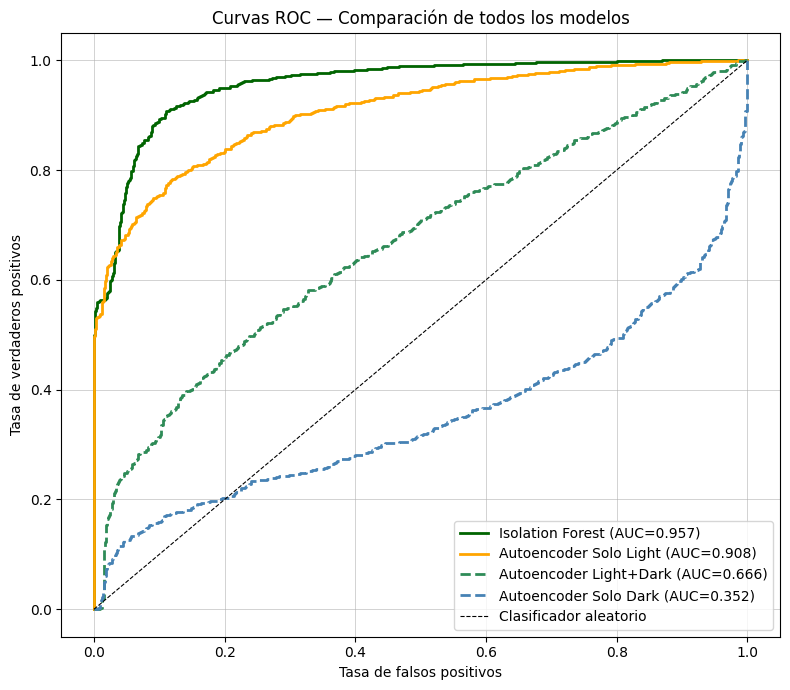

In [ ]:

plt.figure(figsize=(8, 7))
# CNN MODEL
...
plt.plot(fpr_cnn, tpr_cnn, color='steelblue',
         label=f'CNN (AUC={roc_auc:.3f})', linewidth=2)

# Isolation Forest
plt.plot(fpr, tpr, color='darkgreen',
         label=f'Isolation Forest (AUC={roc_auc:.3f})', linewidth=2)

# Autoencoder Solo Light (recupera fpr/tpr del bloque anterior)
fpr_ae, tpr_ae, _ = roc_curve(
    np.concatenate([np.zeros(len(err_light_on_light)),
                    np.ones(len(err_light_on_dark))]),
    np.concatenate([err_light_on_light, err_light_on_dark])
)
plt.plot(fpr_ae, tpr_ae, color='orange',
         label=f'Autoencoder Solo Light (AUC=0.908)', linewidth=2)

# Autoencoder Light+Dark
fpr_ld, tpr_ld, _ = roc_curve(
    np.concatenate([np.zeros(len(err_both_on_light)),
                    np.ones(len(err_both_on_dark))]),
    np.concatenate([err_both_on_light, err_both_on_dark])
)
plt.plot(fpr_ld, tpr_ld, color='seagreen',
         label=f'Autoencoder Light+Dark (AUC=0.666)', linewidth=2, linestyle='--')

# Autoencoder Solo Dark
fpr_sd, tpr_sd, _ = roc_curve(
    np.concatenate([np.zeros(len(err_dark_on_light)),
                    np.ones(len(err_dark_on_dark))]),
    np.concatenate([err_dark_on_light, err_dark_on_dark])
)
plt.plot(fpr_sd, tpr_sd, color='steelblue',
         label=f'Autoencoder Solo Dark (AUC=0.352)', linewidth=2, linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Clasificador aleatorio')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC — Comparación de todos los modelos')
plt.legend(loc='lower right')
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.savefig("roc_comparacion_completa.png", dpi=120)
plt.show()